In [1]:
import os
from glob import glob
import torch
import numpy as np
X_train = np.stack([np.loadtxt(file, dtype=np.float32) for file in glob(os.path.join("train/Inertial Signals", "*.txt"))], axis=-1)
y_train = np.loadtxt("train/y_train.txt", dtype=np.int64) - 1
X_test = np.stack([np.loadtxt(file, dtype=np.float32) for file in glob(os.path.join("test/Inertial Signals", "*.txt"))], axis=-1)
y_test = np.loadtxt("test/y_test.txt", dtype=np.int64) - 1 
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7352, 128, 9), (7352,), (2947, 128, 9), (2947,))

In [2]:
from mp import cvTrain, cvTest
from stateSpaceModel import StateSpaceModel
from Best import CNNLSTM
import optuna

for _ in range(10):
    """
    print("model1")
    params =  {"classes": 6, "dim": 64, 'num_cnn': 0, 'num_lstm': 2}
    model1 = cvTrain(X_train, y_train, CNNLSTM, params, verbose=False)
    y_pred, _ = cvTest(X_test, y_test, model1)

    print("model2")
    params =  {"classes": 6, "dim": 32, 'num_cnn': 1, 'num_lstm': 1}
    model2 = cvTrain(X_train, y_train, CNNLSTM, params, verbose=False)
    y_pred, _ = cvTest(X_test, y_test, model2)
    
    print("model3")
    params =  {"classes": 6, "dim": 16, 'num_cnn': 3, 'num_lstm': 0}
    model3 = cvTrain(X_train, y_train, CNNLSTM, params, verbose=False)
    y_pred, _ = cvTest(X_test, y_test, model3)
    """

[I 2025-12-17 22:30:15,999] A new study created in memory with name: no-name-bf60e0e8-4d74-497f-96d2-3cb97f276a09
C:\Users\Ur451\Desktop\SSM\.venv\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-12-17 22:30:40,892] Trial 0 finished with value: 0.9540264617063684 and parameters: {'dim': 14, 'num_cnn': 3, 'num_lstm': 1, 'dropout': 0.426134877940041, 'kernel1_0': 7, 'kernel1_1': 5, 'kernel1_2': 3, 'kernel2_0': 3, 'kernel2_1': 7, 'kernel2_2': 1}. Best is trial 0 with value: 0.9540264617063684.


0.9540264617063684


In [3]:
def objective(trial):
    params = {
        "classes": 6,
        "dim": trial.suggest_int("dim", 9, 32),
        "num_cnn": trial.suggest_int("num_cnn", 2, 4),
        "num_lstm": trial.suggest_int("num_lstm", 0, 2),
        "dropout": trial.suggest_float("dropout", 0.4, 0.6),
    }
    params["kernels1"] = [trial.suggest_int(f'kernel1_{i}', 1, 7, step=2) for i in range(params["num_cnn"])]
    params["kernels2"] = [trial.suggest_int(f'kernel2_{i}', 1, 7, step=2) for i in range(params["num_cnn"])]

    _, accuracies = cvTrain(X_train, y_train, CNNLSTM, params, epochs=10, trial=trial)
    print(np.mean(accuracies))
    return np.mean(accuracies)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=1)

params = {
    "classes": 6,
    "dim": study.best_params["dim"],
    "num_cnn": study.best_params["num_cnn"],
    "num_lstm": study.best_params["num_lstm"],
    "dropout": study.best_params["dropout"],
    "kernels1": [study.best_params[f"kernel1_{i}"] for i in range(study.best_params["num_cnn"])],
    "kernels2": [study.best_params[f"kernel2_{i}"] for i in range(study.best_params["num_cnn"])]
}
models, _ = cvTrain(X_train, y_train, CNNLSTM, params, epochs=10)
y_pred, _ = cvTest(X_test, y_test, models)

C:\Users\Ur451\Desktop\SSM\.venv\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Accuracy: 0.9328130302002036


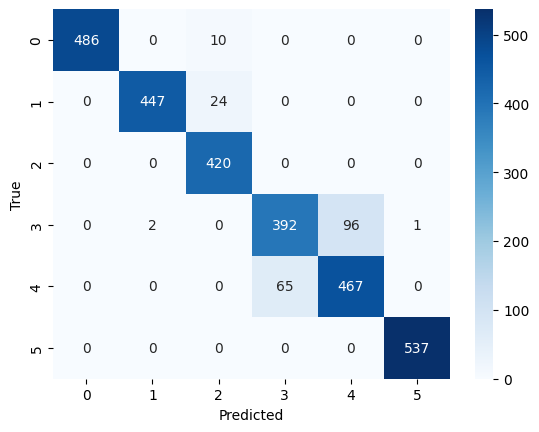

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [5]:
from torchinfo import summary
from mytorch import CNNLSTM
summary(CNNLSTM(6, 64, 0, 2), input_size=(128, 128, 9))

Layer (type:depth-idx)                   Output Shape              Param #
CNNLSTM                                  [128, 6]                  --
├─Sequential: 1-1                        [128, 64, 62]             --
│    └─Conv1d: 2-1                       [128, 64, 62]             2,944
│    └─ReLU: 2-2                         [128, 64, 62]             --
│    └─BatchNorm1d: 2-3                  [128, 64, 62]             128
├─LSTM: 1-2                              [128, 62, 128]            165,888
├─Sequential: 1-3                        [128, 6]                  --
│    └─AdaptiveAvgPool1d: 2-4            [128, 128, 1]             --
│    └─Flatten: 2-5                      [128, 128]                --
│    └─Dropout: 2-6                      [128, 128]                --
│    └─Linear: 2-7                       [128, 6]                  774
Total params: 169,734
Trainable params: 169,734
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 1.34
Input size (MB): 0.59
Forward/bac

In [6]:
summary(CNNLSTM(6, 32, 1, 1), input_size=(128, 128, 9))

C:\Users\Ur451\Desktop\SSM\.venv\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
CNNLSTM                                  [128, 6]                  --
├─Sequential: 1-1                        [128, 32, 62]             --
│    └─Conv1d: 2-1                       [128, 32, 62]             1,472
│    └─ReLU: 2-2                         [128, 32, 62]             --
│    └─BatchNorm1d: 2-3                  [128, 32, 62]             64
├─ModuleList: 1-2                        --                        --
│    └─ModuleDict: 2-4                   --                        --
│    │    └─Sequential: 3-1              [128, 64, 62]             6,208
│    │    └─Sequential: 3-2              [128, 64, 62]             2,112
│    │    └─Sequential: 3-3              [128, 64, 62]             128
├─LSTM: 1-3                              [128, 31, 128]            66,560
├─Sequential: 1-4                        [128, 6]                  --
│    └─AdaptiveAvgPool1d: 2-5            [128, 128, 1]             --
│

In [7]:
summary(CNNLSTM(6, 16, 3, 0), input_size=(128, 128, 9))

Layer (type:depth-idx)                   Output Shape              Param #
CNNLSTM                                  [128, 6]                  --
├─Sequential: 1-1                        [128, 16, 62]             --
│    └─Conv1d: 2-1                       [128, 16, 62]             736
│    └─ReLU: 2-2                         [128, 16, 62]             --
│    └─BatchNorm1d: 2-3                  [128, 16, 62]             32
├─ModuleList: 1-2                        --                        --
│    └─ModuleDict: 2-4                   --                        --
│    │    └─Sequential: 3-1              [128, 32, 62]             1,568
│    │    └─Sequential: 3-2              [128, 32, 62]             544
│    │    └─Sequential: 3-3              [128, 32, 62]             64
│    └─ModuleDict: 2-5                   --                        --
│    │    └─Sequential: 3-4              [128, 64, 31]             6,208
│    │    └─Sequential: 3-5              [128, 64, 31]             2,112
│   